In [ ]:
# ==========================================================
# PETUNJUK UNTUK ANGGOTA KELOMPOK:
# 1. Pastikan folder 'Kelompok2_ComputerVision' sudah di-SHARE ke email Anda.
# 2. Buka "Shared with me" di Google Drive Anda.
# 3. Klik kanan folder tersebut -> "Add shortcut to Drive" -> "My Drive".
# ==========================================================

**Tahap 1**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import os


source = "/content/drive/MyDrive/Kelompok2_ComputerVison"
destination = "/content/drive/MyDrive/Dataset_kelompok2_computerVision"


if os.path.exists(source) and os.path.isdir(source):

    # Tambahan: Bersihkan tujuan jika sudah ada agar tidak duplikat/error
    if os.path.exists(destination):
        shutil.rmtree(destination)
    os.makedirs(destination)

    # Proses penyalinan per item (Supaya tidak terjadi error path berulang)
    for item in os.listdir(source):
        src_path = os.path.join(source, item)
        dst_path = os.path.join(destination, item)

        if os.path.isdir(src_path):
            shutil.copytree(src_path, dst_path)
        else:
            shutil.copy2(src_path, dst_path)

    print("Dataset berhasil dicopy")

else:
    print(f"Error: Direktori sumber '{source}' tidak ditemukan. Mohon perbarui variabel 'source' dengan jalur yang benar.")

Dataset berhasil dicopy


**Tahap 2**

In [ ]:
!pip install facenet-pytorch

In [ ]:
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt
from facenet_pytorch import MTCNN, InceptionResnetV1

In [ ]:
drive_path = '/content/drive/MyDrive/Dataset_kelompok2_computerVision'

if os.path.exists(drive_path):
    print(f"Isi dari '{drive_path}':")
    for item in os.listdir(drive_path):
        item_path = os.path.join(drive_path, item)
        if os.path.isdir(item_path):
            print(f"  [FOLDER] {item}")
        else:
            print(f"  [FILE] {item}")
else:
    print(f"Error: Direktori '{drive_path}' tidak ditemukan. Pastikan Google Drive Anda sudah di-mount dengan benar.")


Isi dari '/content/drive/MyDrive/Dataset_kelompok2_computerVision':
  [FOLDER] rebecca klopper
  [FOLDER] zee asadel
  [FOLDER] bob dylan
  [FOLDER] baskara mahendra
  [FOLDER] mangUcup


SET DEVICE

In [ ]:
# tes dl
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Device:", device)

Device: cpu


**Tahap 3**

LOAD MODEL

In [ ]:
mtcnn = MTCNN(image_size=160, margin=20, device=device)
resnet = InceptionResnetV1(pretrained='vggface2').eval().to(device)

LOAD DATASET & BUILD EMBEDDINGS

In [ ]:
dataset_path = "/content/drive/MyDrive/Dataset_kelompok2_computerVision"

embeddings = []
names = []

for person_name in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person_name)

    if not os.path.isdir(person_path):
        continue

    for file in os.listdir(person_path):
        if file.lower().endswith(('.jpg', '.png', '.jpeg')):

            img_path = os.path.join(person_path, file)
            img = cv2.imread(img_path)

            if img is None:
                continue

            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            face = mtcnn(img_rgb)

            if face is not None:
                face = face.unsqueeze(0).to(device)
                embedding = resnet(face).detach().cpu().numpy()[0]

                embeddings.append(embedding)
                names.append(person_name)

print("Total embedding:", len(embeddings))

Total embedding: 85


FUNCTION COSINE SIMILARITY

In [ ]:
# tes dl
def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

**Tahap 4**

**TEST IMAGE**

In [ ]:
# tes dl
test_image_path = "/content/drive/MyDrive/Dataset_kelompok2_computerVision/mangUcup/6.jpg"


img = cv2.imread(test_image_path)

if img is None:
    raise Exception("Gambar test tidak ditemukan!")
else:
  print("Gambar diTemukan!")

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

boxes, _ = mtcnn.detect(img_rgb)

Gambar diTemukan!


PREDICTION

In [ ]:
# tes dl
if boxes is not None:
    height, width = img.shape[:2]
    # Atur ketebalan garis kotak hijau (sekitar 0.5% dari lebar gambar, minimum 2px)
    thickness = max(3, int(width * 0.005))
    # Atur ukuran teks (font scale) (sekitar 0.1% dari lebar gambar, minimum 0.8)
    font_scale = max(1, width / 1000)
    for box in boxes:
        x1, y1, x2, y2 = map(int, box)

        face = img_rgb[y1:y2, x1:x2]
        face = cv2.resize(face, (160, 160))
        face = torch.tensor(face).permute(2,0,1).float()/255
        face = face.unsqueeze(0).to(device)

        emb = resnet(face).detach().cpu().numpy()[0]

        best_score = -1
        best_name = "Unknown"

        for i, known_emb in enumerate(embeddings):
            score = cosine_similarity(emb, known_emb)

            if score > best_score:
                best_score = score
                best_name = names[i]

        # threshold cosine similarity
        if best_score > 0.6:
            label = best_name
        else:
            label = "Unknown"

        cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), thickness)
        cv2.putText(img, f"{label} ({best_score:.2f})", (x1,y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX, font_scale, (0,255,0), 2)

 SHOW RESULT

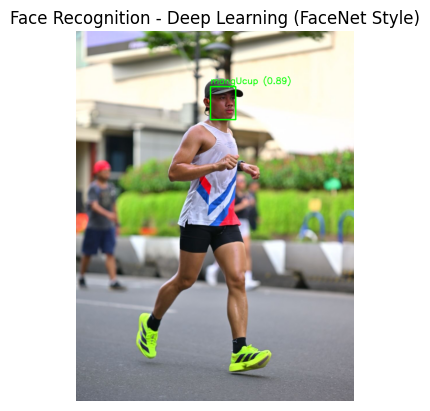

In [ ]:
# tes dl
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Face Recognition - Deep Learning (FaceNet Style)")
plt.axis('off')
plt.show()